In [14]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
file_path = "The Ultimate Cars Dataset 2024.csv"
try:
    data = pd.read_csv(file_path, encoding='latin1')  # Sesuaikan encoding jika diperlukan
except Exception as e:
    print("Error loading file:", e)
    exit()

In [16]:
print("Info Dataset:")
print(data.info())

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Names              1213 non-null   object
 1   Cars Names                 1213 non-null   object
 2   Engines                    1213 non-null   object
 3   CC/Battery Capacity        1210 non-null   object
 4   HorsePower                 1213 non-null   object
 5   Total Speed                1213 non-null   object
 6   Performance(0 - 100 )KM/H  1207 non-null   object
 7   Cars Prices                1213 non-null   object
 8   Fuel Types                 1213 non-null   object
 9   Seats                      1213 non-null   object
 10  Torque                     1212 non-null   object
dtypes: object(11)
memory usage: 104.4+ KB
None


In [36]:
print(data.head())

  Company Names  Cars Names      Engines CC/Battery Capacity HorsePower  \
0       FERRARI         884           V8             3990 cc     963 hp   
1   ROLLS ROYCE         737          V12             6749 cc     563 hp   
2          Ford         607  1.2L Petrol            1,200 cc   70-85 hp   
3      MERCEDES           0           V8            3,982 cc     630 hp   
4          AUDI         138          V10            5,204 cc     602 hp   

  Total Speed Performance(0 - 100 )KM/H      Cars Prices       Fuel Types  \
0    340 km/h                   2.5 sec      $1,100,000   plug in hyrbrid   
1    250 km/h                   5.3 sec        $460,000            Petrol   
2    165 km/h                  10.5 sec  $12,000-$15,000           Petrol   
3    250 km/h                   3.2 sec        $161,000            Petrol   
4    320 km/h                   3.6 sec        $253,290            Petrol   

  Seats        Torque  
0     2        800 Nm  
1     5        900 Nm  
2     5  100 -

In [17]:
print(data.columns)

Index(['Company Names', 'Cars Names', 'Engines', 'CC/Battery Capacity',
       'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Cars Prices',
       'Fuel Types', 'Seats', 'Torque'],
      dtype='object')


In [20]:
selected_columns = ["Cars Names", "Engines", "Torque"]
data_subset = data[selected_columns].dropna()  

In [27]:
label_encoder_cars = LabelEncoder()
label_encoder_engines = LabelEncoder()
data_subset["Cars Names"] = label_encoder_cars.fit_transform(data_subset["Cars Names"])
data_subset["Engines"] = label_encoder_engines.fit_transform(data_subset["Engines"])
data_subset["Torque"] = label_encoder_engines.fit_transform(data_subset["Torque"])

In [28]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_subset)

In [29]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)


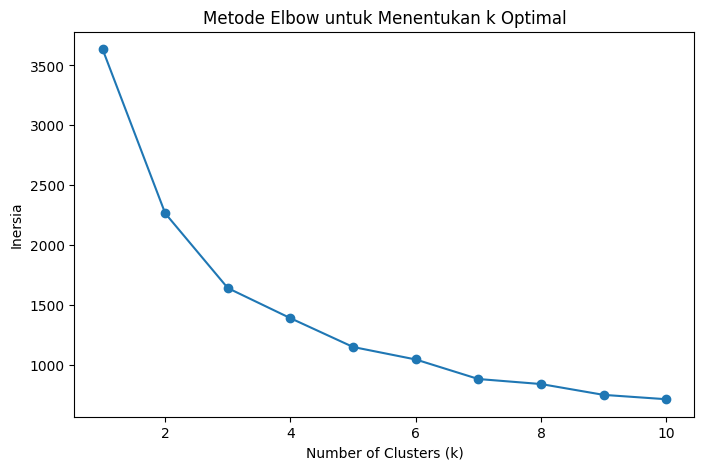

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inersia")
plt.title("Metode Elbow untuk Menentukan k Optimal")
plt.show()

optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data_subset["Cluster"] = kmeans.fit_predict(data_scaled)

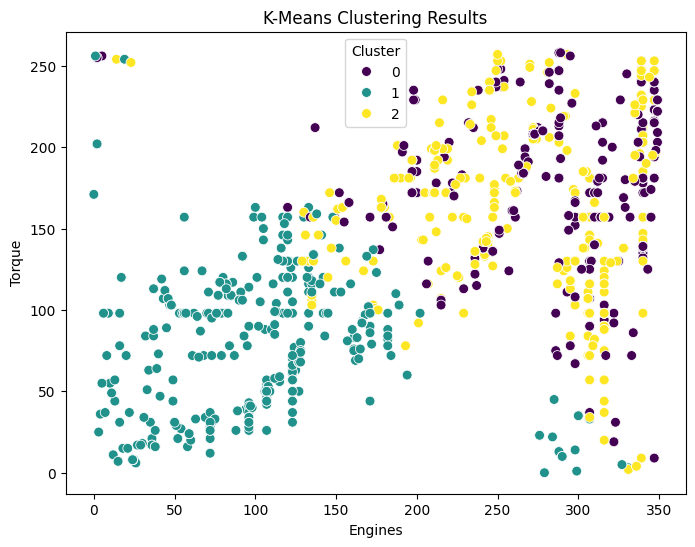

In [31]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=data_subset[selected_columns[1]],  # Engine
    y=data_subset[selected_columns[2]],  # Torque
    hue=data_subset["Cluster"], 
    palette="viridis",
    s=50
)
plt.xlabel("Engines")
plt.ylabel("Torque")
plt.title("K-Means Clustering Results")
plt.legend(title="Cluster")
plt.show()


In [34]:
print(data_subset.head())

   Cars Names  Engines  Torque  Cluster
0         883      347     240        0
1         737      339     253        0
2         607       26       6        1
3           0      347     253        2
4         138      338     194        2
